In [77]:
import warnings
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
warnings.filterwarnings("ignore", category=RuntimeWarning, module="pyogrio.raw")
warnings.filterwarnings("ignore", category=DeprecationWarning)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


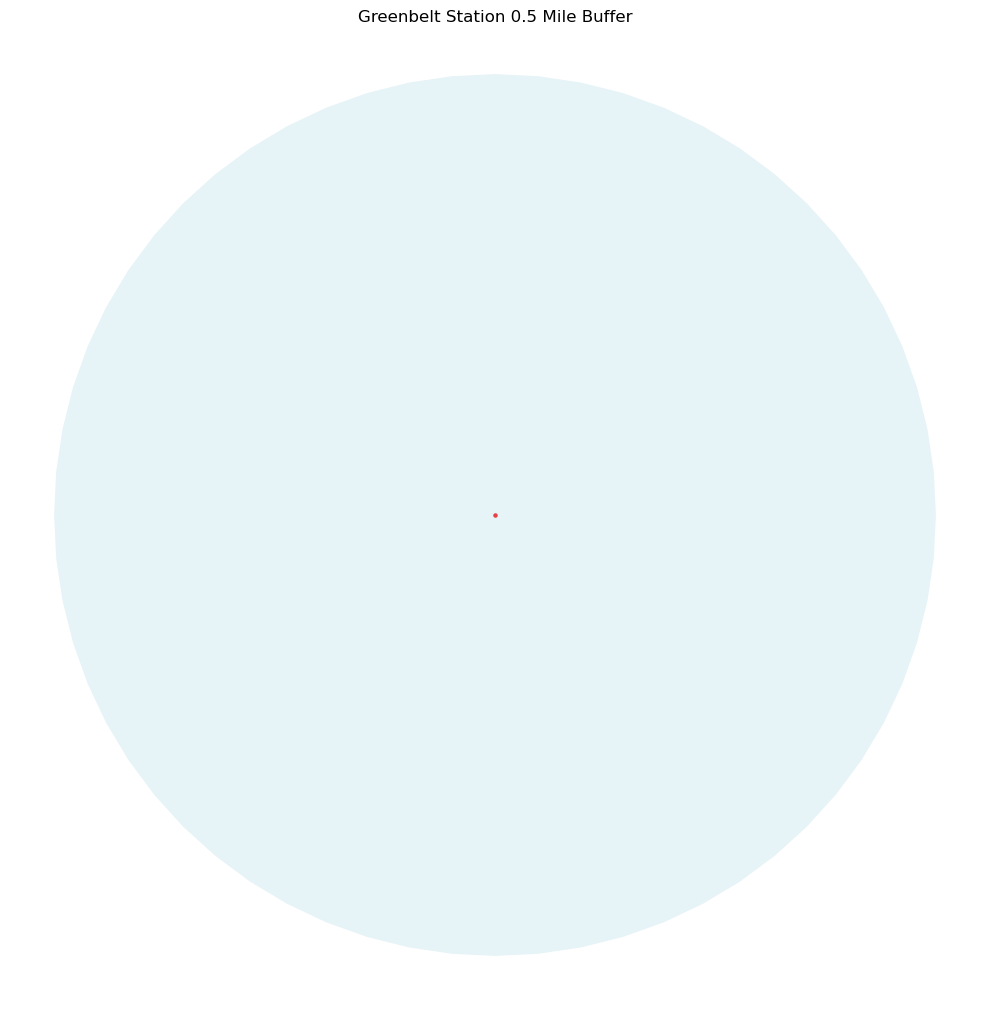

In [55]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load metro stations
metro_stations = gpd.read_file('data/Metro_Stations_Regional.shp')

# Define CRS: EPSG 2248 (NAD83 / Maryland)
crs_projected = 2248  # Units in feet

# Project the Greenbelt station to projected CRS
greenbelt_station = metro_stations[metro_stations['NAME'] == 'Greenbelt'].to_crs(epsg=crs_projected)

# Create a 0.5 mile buffer (2640 feet)
greenbelt_buffer = greenbelt_station.geometry.buffer(2640)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
greenbelt_station.plot(ax=ax, color='red', marker='o', markersize=5)
greenbelt_buffer.plot(ax=ax, color='lightblue', alpha=0.3)
ax.set_axis_off()
plt.tight_layout()
plt.title('Greenbelt Station 0.5 Mile Buffer')
plt.show()

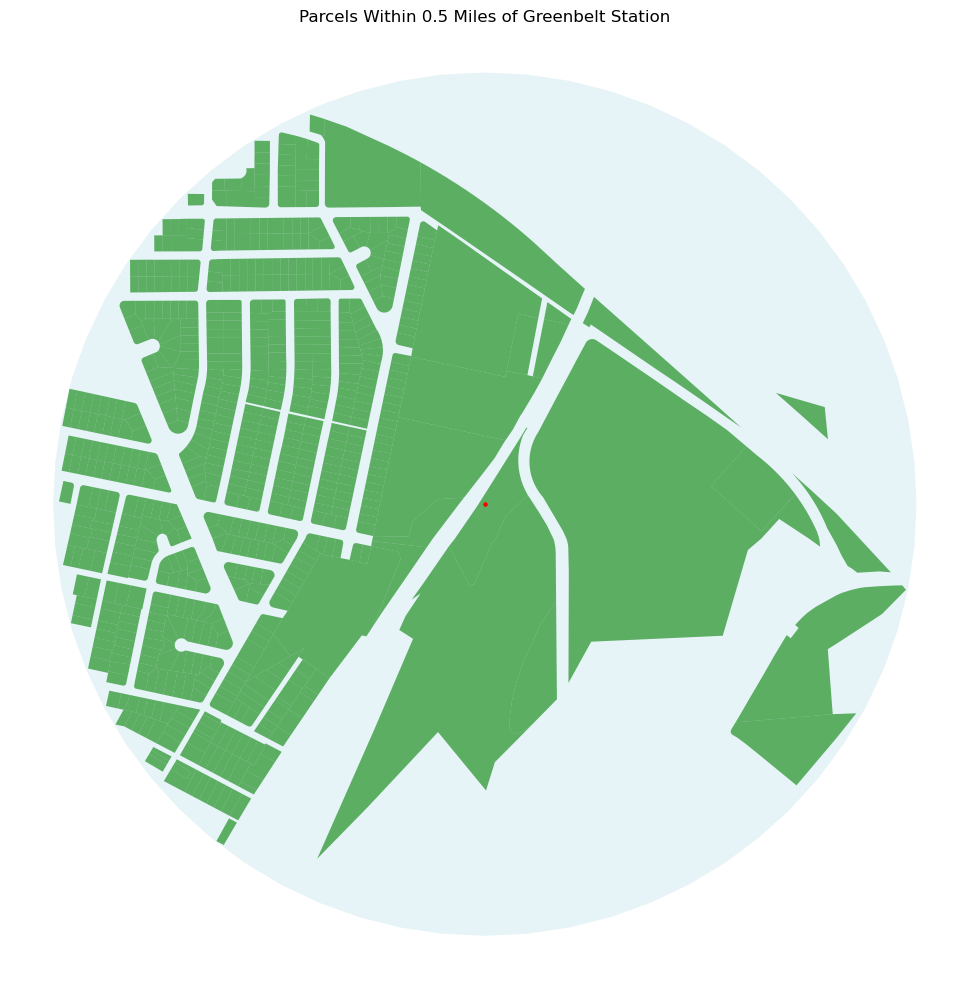

In [56]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load data
property_gdf = gpd.read_file('data/Property_Info_Py.shp')
metro_stations = gpd.read_file('data/Metro_Stations_Regional.shp')

# Define a projected CRS for accurate distance-based operations (in feet)
crs_projected = 2248  # NAD83 / Maryland

# Reproject both datasets to projected CRS
property_gdf = property_gdf.to_crs(epsg=crs_projected)
metro_stations = metro_stations.to_crs(epsg=crs_projected)

# Select the Greenbelt Metro station
greenbelt_station = metro_stations[metro_stations['NAME'] == 'Greenbelt']

# Create a 0.5 mile buffer (2640 feet) around the Greenbelt station
greenbelt_buffer = greenbelt_station.geometry.buffer(2640)

# Convert buffer to GeoDataFrame for spatial filtering
greenbelt_buffer_gdf = gpd.GeoDataFrame(geometry=greenbelt_buffer, crs=f"EPSG:{crs_projected}")

# Spatial filter: keep only parcels within the buffer
greenbelt_buffer_parcels = property_gdf[property_gdf.geometry.within(greenbelt_buffer.iloc[0])]

# Optional: visualize the result
fig, ax = plt.subplots(figsize=(10, 10))
greenbelt_buffer_gdf.plot(ax=ax, color='lightblue', alpha=0.3)
greenbelt_buffer_parcels.plot(ax=ax, color='green', alpha=0.6)
greenbelt_station.plot(ax=ax, color='red', marker='o', markersize=5)
ax.set_axis_off()
plt.title('Parcels Within 0.5 Miles of Greenbelt Station')
plt.tight_layout()
plt.show()


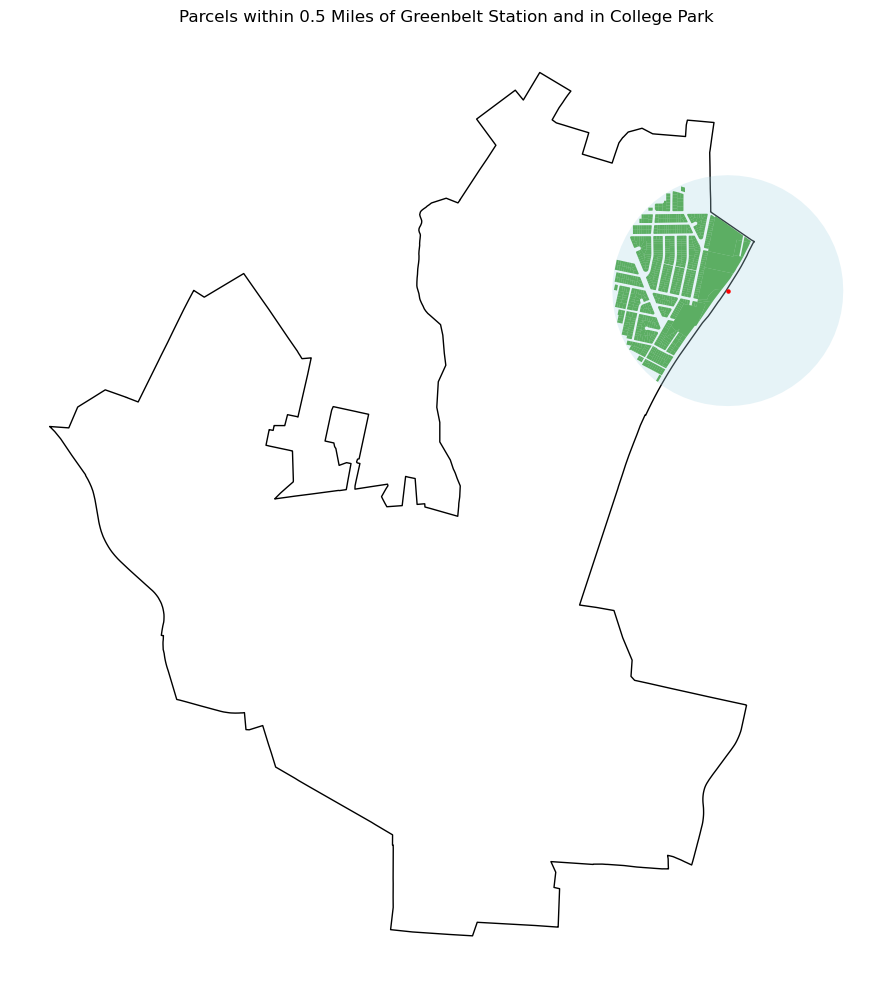

In [57]:
import geopandas as gpd

# Load shapefiles
property_gdf = gpd.read_file('data/Property_Info_Py.shp')
metro_stations = gpd.read_file('data/Metro_Stations_Regional.shp')
muni_boundary = gpd.read_file('data/Municipal_Boundary_Py.shp')

# Define projected CRS for accurate distance and area calculations (EPSG:2248 = NAD83 / Maryland)
crs_projected = 2248

# Reproject all to projected CRS
property_gdf = property_gdf.to_crs(epsg=crs_projected)
metro_stations = metro_stations.to_crs(epsg=crs_projected)
muni_boundary = muni_boundary.to_crs(epsg=crs_projected)

# Filter for Greenbelt station
greenbelt_station = metro_stations[metro_stations['NAME'] == 'Greenbelt']

# Buffer: 0.5 mile = 2640 feet
greenbelt_buffer = greenbelt_station.geometry.buffer(2640)
greenbelt_buffer_geom = greenbelt_buffer.iloc[0]  # single shapely geometry

# Filter for College Park boundary
college_park_boundary = muni_boundary[muni_boundary['CITY'] == 'College Park']
college_park_geom = college_park_boundary.geometry.unary_union  # merged geometry if multipart

# Spatial filter: parcels within both buffer AND College Park
greenbelt_buffer_cp_parcels = property_gdf[
    property_gdf.geometry.within(greenbelt_buffer_geom) &
    property_gdf.geometry.within(college_park_geom)
]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
college_park_boundary.plot(ax=ax, edgecolor='black', facecolor='none')
gpd.GeoSeries(greenbelt_buffer_geom).plot(ax=ax, color='lightblue', alpha=0.3)
greenbelt_buffer_cp_parcels.plot(ax=ax, color='green', alpha=0.6)
greenbelt_station.plot(ax=ax, color='red', marker='o', markersize=5)
ax.set_axis_off()
plt.title('Parcels within 0.5 Miles of Greenbelt Station and in College Park')
plt.tight_layout()
plt.show()


In [78]:
# Count parcels by LAND_USE_D in Greenbelt buffer
print("Greenbelt Buffer Parcel Counts by Land Use:")
print(greenbelt_buffer_parcels['LAND_USE_D'].value_counts(dropna=False))

# Count parcels by LAND_USE_D in College Park portion
print("\nCollege Park Portion Parcel Counts by Land Use:")
print(greenbelt_buffer_cp_parcels['LAND_USE_D'].value_counts(dropna=False))


Greenbelt Buffer Parcel Counts by Land Use:
LAND_USE_D
Standard Unit                                                650
Split Foyer                                                   25
Vacant - Residential Zoning                                   19
Subdivided - Single Family Residential                         2
Split Level                                                    1
Town and Cities - Other                                        1
State of Maryland - Metro, Transit Authority, Wash. Metro      1
Privately Owned Property - Church Schools, E.T.A.              1
Name: count, dtype: int64

College Park Portion Parcel Counts by Land Use:
LAND_USE_D
Standard Unit                                        650
Split Foyer                                           25
Vacant - Residential Zoning                           18
Subdivided - Single Family Residential                 2
Split Level                                            1
Town and Cities - Other                               

In [79]:
# Calculate built density for greenbelt_buffer_parcels
gb_total_units = greenbelt_buffer_parcels['DUS'].sum()
gb_total_acres = greenbelt_buffer_parcels['ACRES'].sum()
greenbelt_buffer_density = gb_total_units / gb_total_acres

# Calculate built density for greenbelt_buffer_cp_parcels
cp_total_units = greenbelt_buffer_cp_parcels['DUS'].sum()
cp_total_acres = greenbelt_buffer_cp_parcels['ACRES'].sum()
greenbelt_cp_buffer_density = cp_total_units / cp_total_acres

print(f"Greenbelt Buffer - Built Density: {greenbelt_buffer_density:.2f} DUs/acre")
print(f"Greenbelt Buffer, College Park - Density: {greenbelt_cp_buffer_density:.2f} DUs/acre")

Greenbelt Buffer - Built Density: 5.46 DUs/acre
Greenbelt Buffer, College Park - Density: 5.76 DUs/acre


In [80]:
# Sum dwelling units in the full Greenbelt buffer
greenbelt_total_units = greenbelt_buffer_parcels['DUS'].sum()

# Sum dwelling units in the College Park portion of the buffer
greenbelt_cp_total_units = greenbelt_buffer_cp_parcels['DUS'].sum()

print(f"Greenbelt Buffer: {greenbelt_total_units:.2f} Dwelling Units (DU)")
print(f"Greenbelt Buffer, College Park: {greenbelt_cp_total_units:.2f} DUs")


Greenbelt Buffer: 676.00 Dwelling Units (DU)
Greenbelt Buffer, College Park: 676.00 DUs


In [61]:
# Assign allowed densities (units/acre) sourced from PG County Zoning Ordinance (EncodePlus)
def assign_allowed_density(row):
    zone = row['ZONE_1']
    use = str(row['LAND_USE_D']).upper()

    if zone == 'RE':
        return 1.08
    elif zone == 'RR':
        return 2.17
    elif zone == 'RSF-95':
        return 4.58
    elif zone == 'RSF-65':
        return 6.7
    elif zone == 'RSF-A':
        return 32.6
    elif zone == 'RMF-20':
        if 'APARTMENT' in use or 'SUBSIDIZED' in use or 'CONDO' in use:
            return 20.0
        elif 'VACANT' in use:
            return 20.0
        elif 'STANDARD' in use or 'SPLIT' in use or 'SUBDIVIDED' in use:
            return 14.0
        else:
            return 14.0
    elif zone == 'RMF-48':
        if 'HI RISE' in use or 'APARTMENT' in use or 'GARDEN' in use or 'SUBSIDIZED' in use:
            return 48.0
        elif 'CONDO' in use or 'RETAIL/APT' in use:
            return 30.0
        elif 'VACANT' in use:
            return 48.0
        else:
            return 24.0
    elif zone == 'RMF-12':
        return 60.0  # Not used much, but you can leave this
    else:
        return None

In [64]:
# Assign allowed density for Greenbelt buffer parcels
greenbelt_buffer_parcels.loc[:, 'allowed_density'] = greenbelt_buffer_parcels.apply(assign_allowed_density, axis=1)
greenbelt_buffer_parcels = greenbelt_buffer_parcels.dropna(subset=['allowed_density'])
greenbelt_buffer_parcels.loc[:, 'max_units'] = greenbelt_buffer_parcels['allowed_density'] * greenbelt_buffer_parcels['ACRES']

# Assign allowed density for College Park portion
greenbelt_buffer_cp_parcels.loc[:, 'allowed_density'] = greenbelt_buffer_cp_parcels.apply(assign_allowed_density, axis=1)
greenbelt_buffer_cp_parcels = greenbelt_buffer_cp_parcels.dropna(subset=['allowed_density'])
greenbelt_buffer_cp_parcels.loc[:, 'max_units'] = greenbelt_buffer_cp_parcels['allowed_density'] * greenbelt_buffer_cp_parcels['ACRES']

# Sum max units
greenbelt_total_max_units = greenbelt_buffer_parcels['max_units'].sum()
greenbelt_cp_total_max_units = greenbelt_buffer_cp_parcels['max_units'].sum()

# Print results
print("Max Units Allowed in Greenbelt Buffer (all parcels):", round(greenbelt_total_max_units))
print("Max Units Allowed in College Park Portion:", round(greenbelt_cp_total_max_units))



Max Units Allowed in Greenbelt Buffer (all parcels): 826
Max Units Allowed in College Park Portion: 787


In [65]:
# Total acres and total allowed units for each set
gb_acres = greenbelt_buffer_parcels['ACRES'].sum()
gb_max_units = greenbelt_buffer_parcels['max_units'].sum()
gb_allowed_density = gb_max_units / gb_acres if gb_acres > 0 else None

cp_acres = greenbelt_buffer_cp_parcels['ACRES'].sum()
cp_max_units = greenbelt_buffer_cp_parcels['max_units'].sum()
cp_allowed_density = cp_max_units / cp_acres if cp_acres > 0 else None

# Print results
print("Allowed Density in Greenbelt Buffer (all parcels):", round(gb_allowed_density, 2), "DU/acre")
print("Allowed Density in College Park Portion:", round(cp_allowed_density, 2), "DU/acre")


Allowed Density in Greenbelt Buffer (all parcels): 6.68 DU/acre
Allowed Density in College Park Portion: 6.7 DU/acre


In [47]:
# Load the datasets 
property_gdf = gpd.read_file('data/Property_Info_Py.shp')  # PG County Property Info dataset
metro_stations = gpd.read_file('data/Metro_Stations_Regional.shp')  # DC, MD, VA Metro Stations
muni_boundary = gpd.read_file('data/Municipal_Boundary_Py.shp') # Municipal Boundaries

# Ensure CRS consistency (WGS84 for everything)
crs_epsg = 4326
property_gdf = property_gdf.to_crs(epsg=crs_epsg)
metro_stations = metro_stations.to_crs(epsg=crs_epsg)
muni_boundary = muni_boundary.to_crs(epsg=crs_epsg)

In [48]:
# Greenbelt Station .5 mile buffer

# Select Greenbelt
greenbelt_station = metro_stations[metro_stations['NAME'] == 'Greenbelt']

# Create a half-mile buffer (2640 feet)
greenbelt_buffer = greenbelt_station.geometry.buffer(2640)


C:\Users\mboch\AppData\Local\Temp\ipykernel_24644\3625309920.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  greenbelt_buffer = greenbelt_station.geometry.buffer(2640)


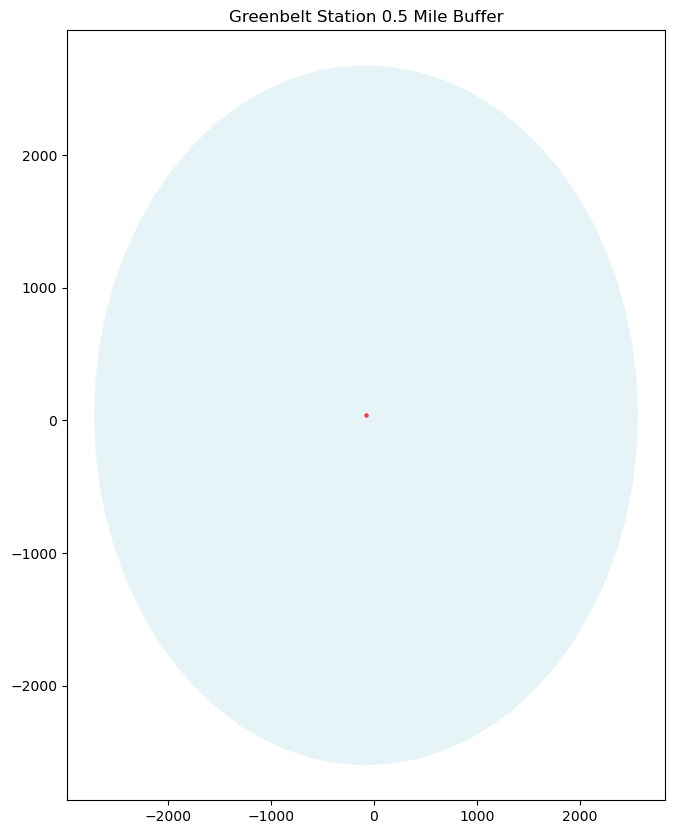

In [50]:
# Visualize the datasets
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot property dataset (PG County properties)
property_gdf.plot(ax=ax, color='green', alpha=0.5)

# Plot greenbelt station
greenbelt_station.plot(ax=ax, color='red', marker='o', markersize=5)

# Plot greenbelt buffer
greenbelt_buffer.plot(ax=ax, color='lightblue', alpha=0.3)

# Set title and show plot
plt.title('Greenbelt Station 0.5 Mile Buffer')
plt.show()

In [37]:
import geopandas as gpd

# Load the datasets 
property_gdf = gpd.read_file('data/Property_Info_Py.shp')  # PG County Property Info dataset
metro_stations = gpd.read_file('data/Metro_Stations_Regional.shp')  # DC, MD, VA Metro Stations
pg_county = gpd.read_file('data/County_Boundary_Py.shp') # PG County Boundary

# Ensure CRS consistency (WGS84 for everything)
crs_epsg = 4326
property_gdf = property_gdf.to_crs(epsg=crs_epsg)
metro_stations = metro_stations.to_crs(epsg=crs_epsg)
pg_county = pg_county.to_crs(epsg=crs_epsg)

# Perform a spatial join to filter metro stations within Prince George's County
stations_pg_county = gpd.sjoin(metro_stations, pg_county, how="inner", predicate='within')

# Display the station names in Prince George's County
print(stations_pg_county['NAME'])


0                     Branch Ave
18                New Carrollton
19                      Landover
20                      Cheverly
21                Downtown Largo
31               Southern Avenue
32                     Greenbelt
36          College Park-U of Md
37               Capitol Heights
38              Morgan Boulevard
47          Hyattsville Crossing
48              West Hyattsville
50    Addison Road-Seat Pleasant
84                   Naylor Road
85                      Suitland
Name: NAME, dtype: object


In [43]:
# Filter for Greenbelt station (you can adjust the 'NAME' value if necessary)
greenbelt_station = metro_stations[metro_stations['NAME'] == 'Greenbelt']
cpumd_station = metro_stations[metro_stations['NAME'] == 'College Park-U of Md']

# Display all information for Greenbelt station
print(greenbelt_station)
print(cpumd_station)

         NAME                                    ADDRESS   LINE  \
32  Greenbelt  5717 GREENBELT METRO DRIVE, GREENBELT, MD  green   

                                           TRAININFO_  \
32  https://www.wmata.com/js/nexttrain/nexttrain.h...   

                                              WEB_URL             GIS_ID  \
32  https://www.wmata.com/rider-guide/stations/gre...  MetroStnFullPt_84   

    MAR_ID                                GLOBALID  OBJECTID CREATOR  \
32     NaN  {E8AB7FE9-199E-458D-A82D-F3AD208546D6}       673    JLAY   

      CREATED EDITOR     EDITED SE_ANNO_CA                    geometry  
32 2022-11-30   JLAY 2024-03-19       None  POINT (-76.91106 39.01115)  
                    NAME                              ADDRESS   LINE  \
36  College Park-U of Md  4931 CALVERT ROAD, COLLEGE PARK, MD  green   

                                           TRAININFO_  \
36  https://www.wmata.com/js/nexttrain/nexttrain.h...   

                                              

In [28]:
# Create a half-mile buffer (distance in feet, as GeoDataFrames typically use CRS with feet units)
# 1 mile = 5280 feet, so 0.5 miles = 2640 feet
greenbelt_buffer = greenbelt_station.geometry.buffer(2640)

# Make sure the CRS matches for both datasets
property_gdf = property_gdf.to_crs(greenbelt_station.crs)

# Reassign the CRS of the greenbelt buffer to match the CRS of the properties shapefile
greenbelt_buffer = greenbelt_buffer.set_crs(property_gdf.crs, allow_override=True)

# Merge the buffer geometries into a single geometry (if necessary)
greenbelt_buffer = greenbelt_buffer.unary_union

# Filter parcels within the half-mile buffer
greenbelt_buffer_parcels = property_gdf[property_gdf.geometry.within(greenbelt_buffer)]

# Display the filtered parcels
print(greenbelt_buffer_parcels)

C:\Users\mboch\AppData\Local\Temp\ipykernel_24644\3232018557.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  greenbelt_buffer = greenbelt_station.geometry.buffer(2640)


       ACCT_PRIMA  ACCT_COUNT            ACCT_OWNER ACCT_OWN_1  ACRES  \
0         0000125           1         KNIGHT ANDREW    Private   0.26   
1         0000133           1     VILLACIS HECTOR A    Private   0.21   
2         0000141           1  RAMOS JULIO & BERTHA    Private   0.15   
3         0000158           1        MCCOY SHERRY G    Private   0.22   
4         0000166           1    JOHNSON OLADUNNI O    Private   0.11   
...           ...         ...                   ...        ...    ...   
271934    9999999           0               UNKNOWN    Unknown   0.01   
271935    9999999           0               UNKNOWN    Unknown   0.23   
271936    9999999           0               UNKNOWN    Unknown   0.06   
271937    9999999           0               UNKNOWN    Unknown   0.04   
271938    9999999           0               UNKNOWN    Unknown   0.07   

                           LAND_USE                              LAND_USE_D  \
0       Residential - Single Family         

In [66]:
print('LAND_USE')

LAND_USE


Property CRS: PROJCS["NAD83(2011) / Maryland (ftUS)",GEOGCS["NAD83(2011)",DATUM["NAD83_National_Spatial_Reference_System_2011",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1116"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",37.6666666666667],PARAMETER["central_meridian",-77],PARAMETER["standard_parallel_1",38.3],PARAMETER["standard_parallel_2",39.45],PARAMETER["false_easting",1312333.33333333],PARAMETER["false_northing",0],UNIT["US survey foot",0.304800609601219,AUTHORITY["EPSG","9003"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Metro Stations CRS: EPSG:3857
PG County CRS: COMPD_CS["NAD83 / Maryland (ftUS) + NAVD88 height",PROJCS["NAD83 / Maryland (ftUS)",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJEC

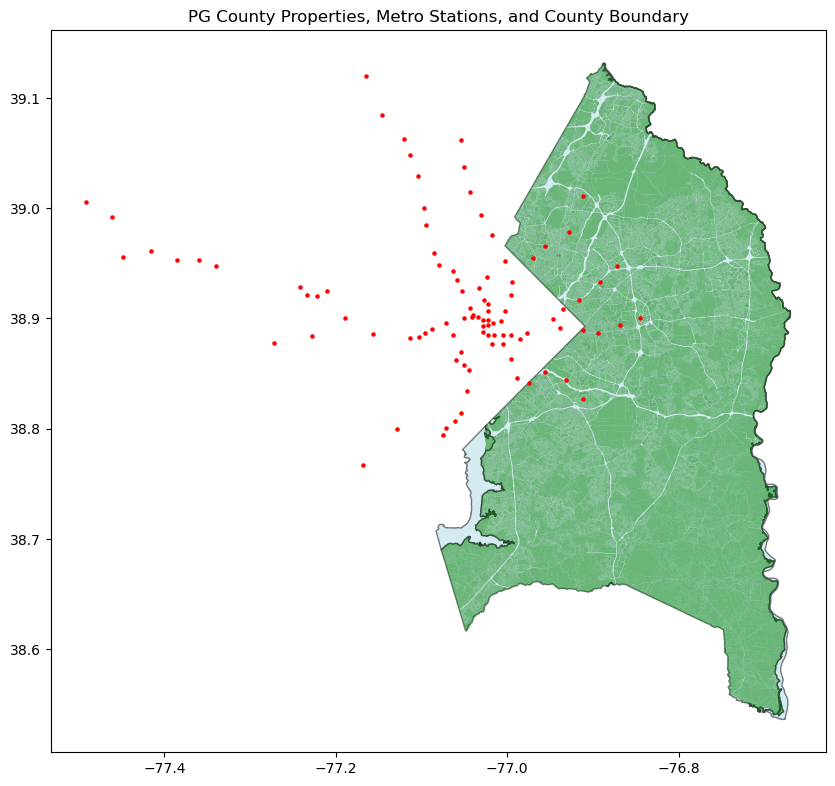

In [5]:
# Check the CRS of each dataset
print(f"Property CRS: {property_gdf.crs}")
print(f"Metro Stations CRS: {metro_stations.crs}")
print(f"PG County CRS: {pg_county.crs}")

# If the CRS are not the same, reproject to a common CRS (WGS84: EPSG:4326)
crs_epsg = 4326

# Reproject datasets if necessary
if property_gdf.crs != crs_epsg:
    property_gdf = property_gdf.to_crs(epsg=crs_epsg)
if metro_stations.crs != crs_epsg:
    metro_stations = metro_stations.to_crs(epsg=crs_epsg)
if pg_county.crs != crs_epsg:
    pg_county = pg_county.to_crs(epsg=crs_epsg)

# Visualize the datasets
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot PG County boundary
pg_county.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)

# Plot property dataset (PG County properties)
property_gdf.plot(ax=ax, color='green', alpha=0.5)

# Plot metro stations
metro_stations.plot(ax=ax, color='red', marker='o', markersize=5)

# Set title and show plot
plt.title('PG County Properties, Metro Stations, and County Boundary')
plt.show()

              NAME                    geometry
0       Branch Ave  POINT (-76.91147 38.82645)
18  New Carrollton  POINT (-76.87184 38.94779)
19        Landover   POINT (-76.8912 38.93351)
20        Cheverly  POINT (-76.91663 38.91664)
21  Downtown Largo  POINT (-76.84455 38.90061)


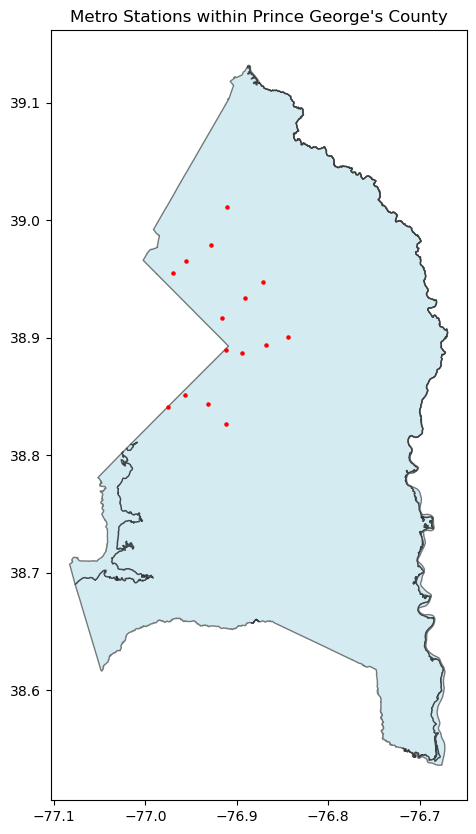

In [6]:
from geopandas.tools import sjoin

# Perform the spatial join to find metro stations within PG County
metro_stations_pg = gpd.sjoin(metro_stations, pg_county, how='inner', predicate='within')

# Check the results
print(metro_stations_pg[['NAME', 'geometry']].head())

# Optional: visualize to confirm
fig, ax = plt.subplots(figsize=(10, 10))
pg_county.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)
metro_stations_pg.plot(ax=ax, color='red', marker='o', markersize=5)
plt.title('Metro Stations within Prince George\'s County')
plt.show()


In [8]:
metro_stations_pg_buffer = metro_stations_pg.to_crs(epsg=6487)  # Project to a feet/meters CRS if needed
metro_stations_pg_buffer['geometry'] = metro_stations_pg_buffer.buffer(804.672)  # ½ mile in meters
property_gdf_proj = property_gdf.to_crs(metro_stations_pg_buffer.crs)
properties_within_buffer = gpd.sjoin(
    property_gdf_proj,
    metro_stations_pg_buffer,
    predicate='within',
    how='inner',
    rsuffix='_station'  # avoids conflict with existing 'index_right'
)

In [9]:
num_properties = properties_within_buffer.shape[0]
print(f"Total number of properties: {num_properties}")


Total number of properties: 11893


In [10]:
# Calculate total buffer area (may include overlapping areas)
total_buffer_area_m2 = metro_stations_pg_buffer.unary_union.area
total_buffer_area_acres = total_buffer_area_m2 / 4046.86
print(f"Total buffer area: {total_buffer_area_acres:.2f} acres")


Total buffer area: 7525.08 acres


In [11]:
properties_within_buffer.columns


Index(['ACCT_PRIMA', 'ACCT_COUNT', 'ACCT_OWNER', 'ACCT_OWN_1', 'ACRES',
       'LAND_USE', 'LAND_USE_D', 'DUS', 'DUS_OWNER_', 'DUS_RENTER',
       'BLDG_SQFT_', 'BLDG_SQFT1', 'BLDG_SQF_1', 'BLDG_YEAR_', 'VALU_LAND',
       'VALU_IMPS', 'VALU_TOTAL', 'LINK_SDAT', 'ZONE_TYPE', 'ZONE_1',
       'ZONE_1_PCT', 'ZONE_2', 'ZONE_2_PCT', 'ZONE_3', 'ZONE_3_PCT', 'ZONE_4',
       'ZONE_4_PCT', 'ZONE_5', 'ZONE_5_PCT', 'LBCS_ACTIV', 'LBCS_FUNCT',
       'LBCS_STRUC', 'PARCEL_COU', 'SHAPE_AREA_left', 'SHAPE_LEN_left',
       'geometry', 'index__station', 'NAME', 'ADDRESS', 'LINE', 'TRAININFO_',
       'WEB_URL', 'GIS_ID', 'MAR_ID', 'GLOBALID', 'OBJECTID', 'CREATOR',
       'CREATED', 'EDITOR', 'EDITED', 'SE_ANNO_CA', 'index_right', 'LAND_TYPE',
       'ACREAGE', 'SHAPE_AREA__station', 'SHAPE_LEN__station'],
      dtype='object')

In [13]:
# Step 1: Total dwelling units within buffer
total_dwelling_units = properties_within_buffer['DUS'].sum()

# Step 2: Total buffer area in acres (excluding overlapping buffers)
total_buffer_area_m2 = metro_stations_pg_buffer.unary_union.area
total_buffer_area_acres = total_buffer_area_m2 / 4046.86

# Step 3: Dwelling units per acre
du_per_acre = total_dwelling_units / total_buffer_area_acres

print(f"Total dwelling units: {total_dwelling_units}")
print(f"Total buffer area (acres): {total_buffer_area_acres:.2f}")
print(f"Dwelling units per acre: {du_per_acre:.2f}")



Total dwelling units: 22006
Total buffer area (acres): 7525.08
Dwelling units per acre: 2.92


ValueError: aspect must be finite and positive 

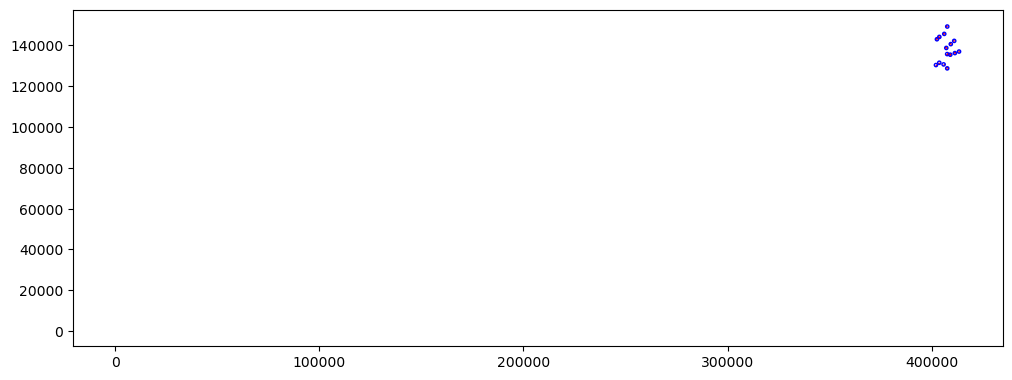

In [16]:
# Plot the map again, this time explicitly setting the aspect ratio
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the buffer area around metro stations
metro_stations_pg_buffer.boundary.plot(ax=ax, color='blue', linewidth=1, label='½-mile buffer')

# Plot all properties in the county for context
property_gdf.plot(ax=ax, color='lightgrey', markersize=1, label='All Properties')

# Plot properties within buffer (used in the density calculation)
properties_within_buffer.plot(ax=ax, color='red', markersize=1, label='Properties within Buffer')

# Plot metro stations within PG County
metro_stations_pg_county.plot(ax=ax, color='black', markersize=20, marker='x', label='Metro Stations')

# Add legend and title
plt.legend()
plt.title('Properties Within ½-Mile of PG County Metro Stations', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# Set equal aspect ratio
ax.set_aspect('equal', adjustable='box')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()
